In [39]:
import pandas as pd

df = pd.read_csv('D:/Downloads/APT_combined.csv', low_memory=False)

In [40]:
print(df.columns)

Index(['Unnamed: 0', 'id', 'expiration_id', 'src_ip', 'src_mac', 'src_oui',
       'src_port', 'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol',
       'ip_version', 'vlan_id', 'tunnel_id', 'bidirectional_first_seen_ms',
       'bidirectional_last_seen_ms', 'bidirectional_duration_ms',
       'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms',
       'src2dst_last_seen_ms', 'src2dst_duration_ms', 'src2dst_packets',
       'src2dst_bytes', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
       'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes',
       'bidirectional_min_ps', 'bidirectional_mean_ps',
       'bidirectional_stddev_ps', 'bidirectional_max_ps', 'src2dst_min_ps',
       'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps',
       'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps',
       'dst2src_max_ps', 'bidirectional_min_piat_ms',
       'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms',
       'bidirectional_max_piat

In [41]:
df.value_counts('Stage')

Stage
Lateral Movement      27445
Establish Foothold    27111
Data Exfiltration      7522
Reconnaissance          685
Cover up                362
Name: count, dtype: int64

In [42]:
list_features = [
    'bidirectional_stddev_ps',
    'bidirectional_mean_ps',
    'dst2src_duration_ms',
    'src2dst_duration_ms',
    'bidirectional_bytes',
    'bidirectional_packets',
    'bidirectional_duration_ms',
    'src2dst_packets',
    'dst2src_packets',
    'src2dst_bytes',
    'dst2src_bytes',
    'bidirectional_mean_piat_ms',
    'bidirectional_stddev_piat_ms',
    'bidirectional_max_piat_ms',
    'bidirectional_min_piat_ms',
    'src2dst_mean_piat_ms',
    'src2dst_stddev_piat_ms',
    'src2dst_max_piat_ms',
    'src2dst_min_piat_ms',
    'dst2src_mean_piat_ms',
    'dst2src_stddev_piat_ms',
    'dst2src_max_piat_ms',
    'dst2src_min_piat_ms',
    'bidirectional_fin_packets',
    'bidirectional_syn_packets',
    'bidirectional_rst_packets',
    'bidirectional_psh_packets',
    'bidirectional_ack_packets',
    'bidirectional_urg_packets',
    'bidirectional_cwr_packets',
    'bidirectional_ece_packets',
    'locate',
    'Stage'
]

df = df[list_features]

In [43]:
import pandas as pd

stage_mapping = {
    'Reconnaissance': 0,     
    'Establish Foothold': 1,
    'Lateral Movement': 2,
    'Data Exfiltration': 3,
    'Cover up': 4
}

In [44]:
df['Stage'] = df['Stage'].map(stage_mapping)

In [45]:
df['Stage'].value_counts()

Stage
2    27445
1    27111
3     7522
0      685
4      362
Name: count, dtype: int64

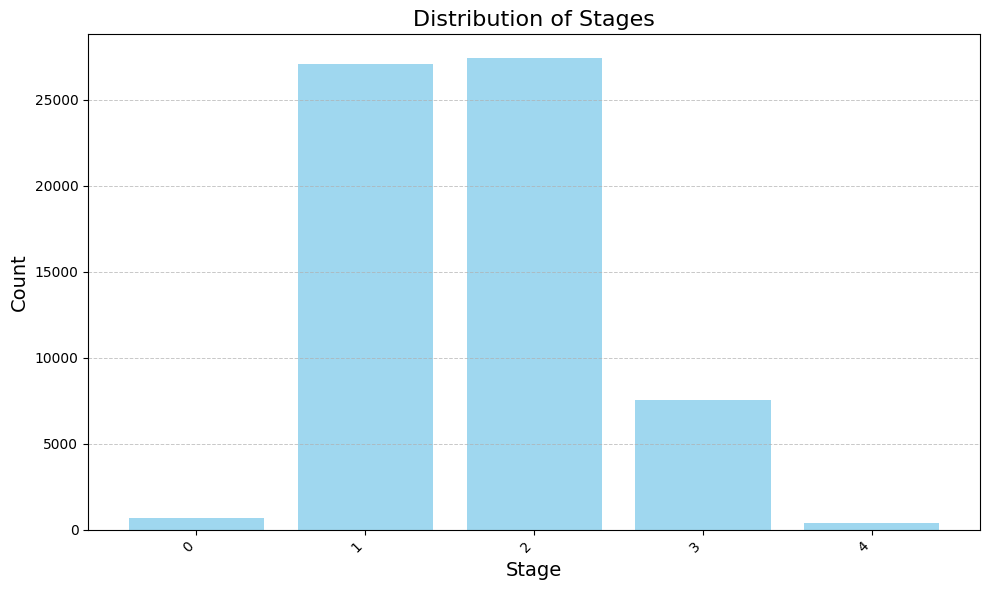

In [46]:
import matplotlib.pyplot as plt
# Đếm số lượng mẫu cho từng nhãn
stage_counts = df['Stage'].value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(stage_counts.index, stage_counts.values, color='skyblue', alpha=0.8)

# Thêm nhãn, tiêu đề và lưới
plt.title('Distribution of Stages', fontsize=16)
plt.xlabel('Stage', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(ticks=stage_counts.index, labels=[
    '0',
    '1',
    '2',
    '3',
    '4'
], rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [33]:
from sklearn.utils import resample
import pandas as pd

# Định nghĩa số lượng mẫu mong muốn cho từng nhãn
desired_samples = {
    0: 658,
    1: 1000,
    2: 3000,
    3: 3000,
    4: 362
    # 5: 359
}

# Chia dữ liệu thành từng nhãn và resample theo số lượng mong muốn
df_balanced = pd.concat([
    resample(
        df[df['Stage'] == stage],
        replace=False,  # Không thay thế
        n_samples=desired_samples[stage],  # Số lượng mẫu mong muốn
        random_state=42
    )
    for stage in desired_samples.keys()
])

# Kiểm tra kết quả
print(df_balanced['Stage'].value_counts())

Stage
2    3000
3    3000
1    1000
0     658
4     362
Name: count, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df_balanced.drop('Stage', axis=1)
y = df_balanced['Stage']
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [35]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
xgb_apt2021 = xgb.XGBClassifier(random_state = 42)

In [36]:
xgb_apt2021.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [37]:
y_pred = xgb_apt2021.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print(classification_report(y_test, y_pred))

0.9501246882793017
[[131   0   1   0   0]
 [  0 190   0  10   0]
 [  0   0 599   1   0]
 [  1  31   0 556  12]
 [  0   0   0  24  48]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       132
           1       0.86      0.95      0.90       200
           2       1.00      1.00      1.00       600
           3       0.94      0.93      0.93       600
           4       0.80      0.67      0.73        72

    accuracy                           0.95      1604
   macro avg       0.92      0.91      0.91      1604
weighted avg       0.95      0.95      0.95      1604


In [38]:
import joblib

# Lưu mô hình vào file
joblib.dump(xgb_apt2021, "D:/code/python/code/ScoreFactor/modeltest/xgb_apt2021.pkl")

print("✅ Mô hình đã được lưu thành công!")

✅ Mô hình đã được lưu thành công!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_apt2021 = RandomForestClassifier(random_state = 42)

In [ ]:
rf_apt2021.fit(x_train, y_train)

In [ ]:
y_pred = rf_apt2021.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print(classification_report(y_test, y_pred))